Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel$\rightarrow$Restart) and then **run all cells** (in the menubar, select Cell$\rightarrow$Run All).

Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE".

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.distributions as dist
%matplotlib inline

# Part 1: The seven scientists

This example is due to [MacKay 2003, exercise 22.15] and [Lee & Wagenmaker 2013, section 4.2].

Suppose seven scientists all go and perform the same experiment, each collecting a measurement $x_i$ for $i = 1,\dots,7$, of an underlying physical value $\mu$. 
 
These scientists are varyingly good at their job, and while we can assume each scientist would estimate $\mu$ correctly _on average_, some of them may have much more error in their measurements than others.

They come back with the following seven observations:


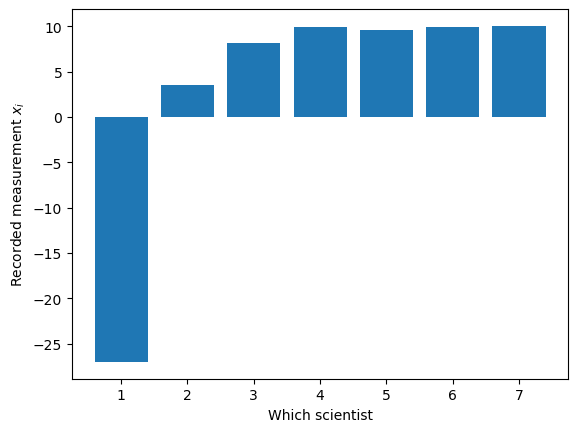

In [2]:
measurements = torch.FloatTensor([-27.020, 3.570, 8.191, 9.898, 9.603, 9.945, 10.056])

plt.bar(np.arange(1,8), measurements) # , "o")
plt.xlabel("Which scientist")
plt.ylabel("Recorded measurement $x_i$");

From looking at the plot, clearly one scientist does not know what they are doing (and some of the others are probably a little suspect too)!


### A model for the data

In this exercise we will suppose that there is "scientist-specific" standard deviation $\sigma_i$, which describes how accurately each of them might perform the experiment:

$$\begin{align}
x_i &\sim \mathrm{Normal}(\mu, \sigma_i^2).
\end{align}$$

Scientists with low $\sigma_i$ produce good estimates of $x$, whereas scientists with high $\sigma_i$ might have wildly inaccurate estimates. However, we don't know _which_ scientists are good -- and we only have one observation from each!

We can ask two questions:

* What is the "real" value of $\mu$?
* What are the values of $\sigma_i$ for each scientists?



### Bayesian inference approach

You will have to choose priors for the mean $\mu$ of the measurements, and for the error standard deviation $\sigma\_i$ for each of the $i$ scientists. A good starting point is

$$\begin{align}
\mu &\sim \mathrm{Normal}(0, \alpha^2) \\
\sigma_i &\sim \mathrm{Exponential}(\beta)
\end{align}$$

where $\alpha=50$ and $\beta=0.5$. This is a prior distribution with mean 2 that places diminishing probability density on larger values of $\sigma_i$:


<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_851496/1639954671.py:4: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel("$\sigma$")
/tmp/ipykernel_851496/1639954671.py:5: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel("$p(\sigma)$")


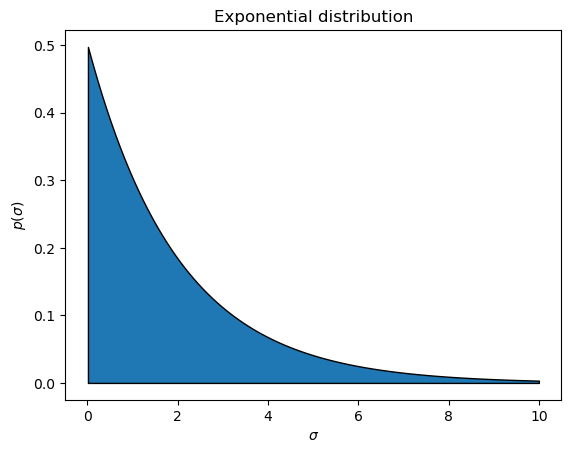

In [3]:
plt.fill_between(np.linspace(0.01,10,100), 0.0, 
                 dist.Exponential(rate=0.5).log_prob(torch.linspace(0.01,10,100)).exp(), 
                 edgecolor='k');
plt.xlabel("$\sigma$")
plt.ylabel("$p(\sigma)$")
plt.title("Exponential distribution");

# TASK #1 (3 points): Define the model

Given $\alpha=50, \beta=0.5$, and the measurements $x$ above, write a function to compute the unnormalized log density

$$\log p(\mu, x_1,\dots,x_7, \sigma_1,\dots, \sigma_7 | \alpha, \beta)$$

In [4]:
def log_joint(mu, sigma, alpha=50, beta=0.5):
    """
    INPUT:
    mu    : scalar
    sigma : tensor, vector of length 7. Should have sigma > 0
    alpha : scalar, standard deviation of Gaussian prior on mu. Default to 50
    beta  : scalar, rate of exponential prior on sigma_i. Default to 0.5

    OUTPUT:
    log_joint: the log probability log p(mu, sigma, x | alpha, beta), scalar
    
    NOTE: For inputs where sigma <= 0, please return negative infinity!

    """
    assert mu.ndim == 0
    assert sigma.shape == (7,)
    
    # YOUR CODE HERE
    if torch.gt(sigma, 0).all():
        # log prior of mu
        log_prior_mu = dist.Normal(0, alpha).log_prob(mu)
        log_prior_sigma = dist.Exponential(rate=beta).log_prob(sigma).sum(0)
        log_x = dist.Normal(mu, sigma).log_prob(measurements).sum(0)
        return log_prior_mu + log_prior_sigma + log_x
    else:
        return -torch.inf

#### Ignore the following cells. 

They consist of "hidden" test cases, and are used by the grading system.

In [86]:
# (GRADING)

In [87]:
# (GRADING)

# TASK #2 (5 points): Implement an MCMC sampler

Your second task is to implement an MCMC algorithm to sample from the posterior distribution

$$p(\mu, \sigma | x, \alpha, \beta).$$

To do this, you need to implement two functions:

* `get_mcmc_proposal`: this takes in current values of $\mu$ and $\sigma$, and returns pytorch `Distribution` objects (i.e., `torch.distributions.Distribution`, here in-scope as `dist.Distribution`) that will propose a next value given the current value, $q(\mu' | \mu, \dots)$ and $q(\sigma' | \sigma, \dots)$. It is **your choice** what sort of distribution to use here! Just make sure that whatever you propose works well in your MCMC algorithm.

* `mcmc_step`: this takes in current values of $\mu$ and $\sigma$, and runs a single Metropolis-Hastings step:
  1. sample candidate values from the proposal distribution you defined
  2. compute an acceptance probability, and either accept or reject
  3. return $\mu, \sigma$

In [11]:
def get_mcmc_proposal(mu, sigma):
    """
    INPUT:
    mu    : scalar
    sigma : tensor, vector of length 7. Should have sigma > 0

    OUTPUT:
    q_mu    : instance of Distribution class, that defines a proposal for mu
    q_sigma : instance of Distribution class, that defines a proposal for sigma
    """
    
    # YOUR CODE HERE
    # Propose q(mu'| mu) ~ N(mu, 0.3)
    # Propose q(sigma' | sigma) ~ LN(log(sigma), 0.2)
    step_size_mu = 0.3
    step_size_sigma = 0.2
    if sigma.gt(0).all():
        q_mu = dist.Normal(mu, step_size_mu)
        q_sigma = dist.LogNormal(torch.log(sigma), step_size_sigma)
        return q_mu, q_sigma
    else:
        raise ValueError("Sigma should be always positive")


### Quick self-check!

If your `get_mcmc_proposal` has the correct function signature, all the following assertions should be true:

In [12]:
q_mu, q_sigma = get_mcmc_proposal(torch.tensor(9.0), torch.ones(7))
assert isinstance(q_mu, dist.Distribution)
assert isinstance(q_sigma, dist.Distribution)
assert q_mu.sample().shape == ()
assert q_sigma.sample().shape == (7,)
del q_mu, q_sigma

In [13]:
def mcmc_step(mu, sigma, alpha=50, beta=0.5):
    """
    mu    : scalar
    sigma : tensor, vector of length 7. Should have sigma > 0
    alpha : scalar, standard deviation of Gaussian prior on mu. Default to 50
    beta  : scalar, rate of exponential prior on sigma_i. Default to 0.5

    OUTPUT:
    mu       : the next value of mu in the MCMC chain
    sigma    : the next value of sigma in the MCMC chain
    accepted : a boolean value, indicating whether the proposal was accepted

    """
    
    accepted = False
    q_mu, q_sigma = get_mcmc_proposal(mu, sigma)
    
    # YOUR CODE HERE
    mu_sample = q_mu.sample()
    sigma_sample = q_sigma.sample()
    new_log_prob = log_joint(mu_sample, sigma_sample, alpha, beta)
    old_log_prob = log_joint(mu, sigma, alpha, beta)

    log_q_sigma_proposal_given_sigma = q_sigma.log_prob(sigma_sample).sum()
    q_sigma_reverse = dist.LogNormal(torch.log(sigma_sample), q_sigma.scale)
    log_q_sigma_given_sigma_proposal = q_sigma_reverse.log_prob(sigma).sum()

    A_prob = torch.exp(new_log_prob - old_log_prob + log_q_sigma_given_sigma_proposal - log_q_sigma_proposal_given_sigma)
    accepted = dist.Uniform(0, 1).sample() < A_prob
    new_mu = mu
    new_sigma = sigma
    if accepted:
        new_mu = mu_sample
        new_sigma = sigma_sample
    return new_mu, new_sigma, accepted

## Running MCMC

We've supplied the outer loop for you -- it will call and execute your `mcmc_step` function. You should *not* need to edit it!

You do need to fill in the function `algo_parameters`, though, which just returns the total number of iterations you decide to run the MCMC chain, and the number of samples to discard as "burnin".

In [14]:
def run_mcmc(N_iters, mu_init, sigma_init):
    """ Run an MCMC algorithm for a fixed number of iterations """
    
    mu_chain = [mu_init]
    sigma_chain = [sigma_init]
    N_accepted = 0
    for _ in range(N_iters):
        mu, sigma, accepted = mcmc_step(mu_chain[-1], sigma_chain[-1])
        mu_chain.append(mu)
        sigma_chain.append(sigma)
        N_accepted += accepted
    
    return torch.stack(mu_chain), torch.stack(sigma_chain), N_accepted / N_iters

In [22]:
def algo_parameters():
    """ TODO: set these to appropriate values:
    
    OUTPUT:
    N_samples : total number of MCMC steps
    N_burnin  : number of initial steps to discard
    """
    
    # YOUR CODE HERE
    
    N_samples = 20000
    N_burnin = 2000
    return N_samples, N_burnin

## Initialize, run, and display diagnostics

The following code initializes the MCMC sampler, executes it for the number of iterations you specified, and then plots a handful of diagnostics.

Use these diagnostics to decide whether or not you have done this properly! Take some time to try to interpret the results, and feel free to play around with the plots a bit.

In [23]:
mu_init = measurements.mean()
sigma_init = torch.ones(7)

N_samples, N_burnin = algo_parameters()

mu_chain, sigma_chain, accepted = run_mcmc(N_samples, mu_init, sigma_init)
print("acceptance rate:", accepted)

acceptance rate: tensor(0.3068)


<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_851496/2920453112.py:3: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mu$")
/tmp/ipykernel_851496/2920453112.py:6: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("$\mu$")


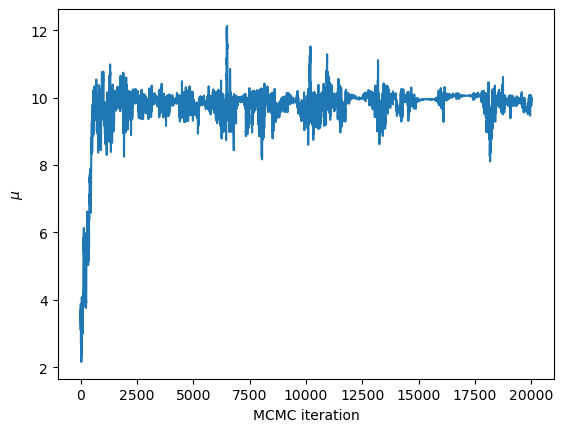

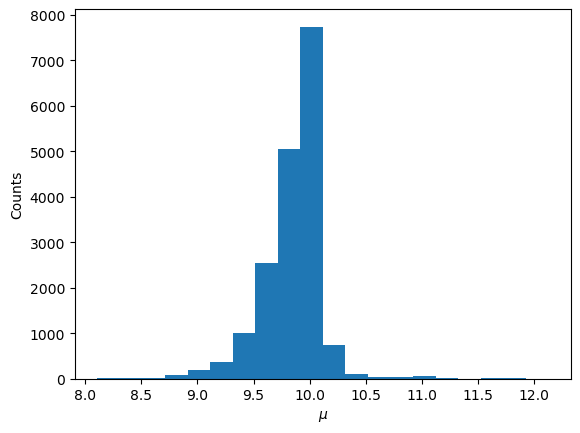

In [24]:
plt.plot(mu_chain);
plt.xlabel("MCMC iteration");
plt.ylabel("$\mu$")
plt.figure();
plt.hist(mu_chain[N_burnin:].numpy(), bins=20);
plt.xlabel("$\mu$")
plt.ylabel("Counts");

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_851496/1079867295.py:5: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel("$\sigma_i$");


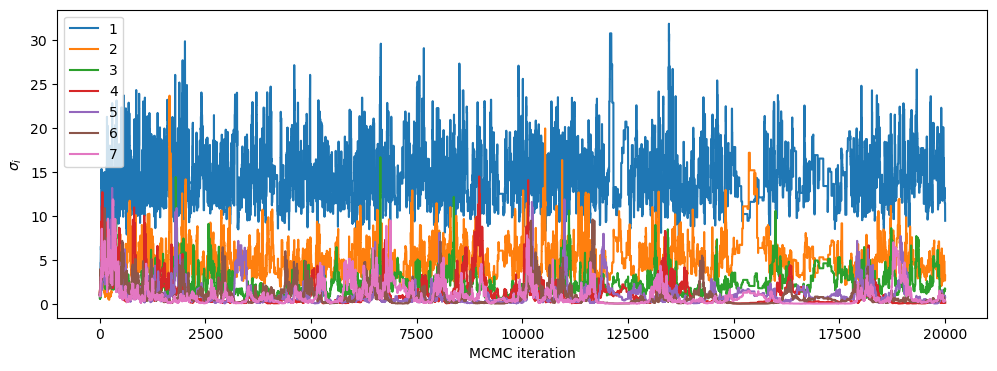

In [25]:
plt.figure(figsize=(12,4));
plt.plot(sigma_chain)
plt.legend(range(1,8));
plt.xlabel("MCMC iteration")
plt.ylabel("$\sigma_i$");

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_851496/2243842497.py:3: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel("Estimated measurement std $\sigma_i$");


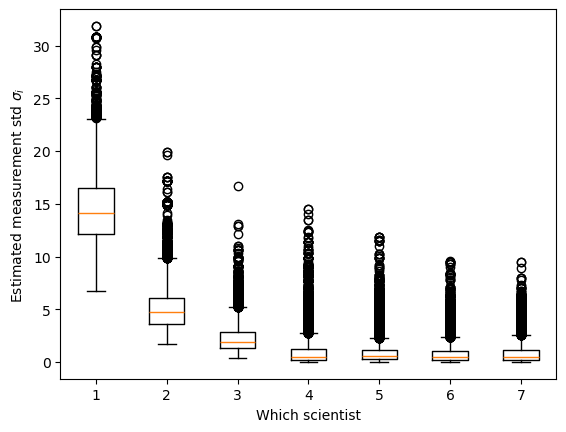

In [26]:
plt.boxplot(sigma_chain[N_burnin:].T, positions=np.arange(1, 8));
plt.xlabel("Which scientist")
plt.ylabel("Estimated measurement std $\sigma_i$");

# TASK #3 (2 points): Estimate posterior expectations

We're specifically interested in using the samples to answer the following:

1. What is the expected value of $\mu$, i.e., $\mathbb{E}[\mu ]$, under the posterior distribution?
2. What is the posterior probability that $\mu$ is less than 9, i.e. $\Pr(\mu < 9.0)$?

Both of these questions can be answered by using samples from your MCMC chain.

In [27]:
def estimate_E_mu(mu_chain, sigma_chain, N_burnin):
    """ Estimate E[mu] 
    
    INPUTS:
    mu_chain    : sequence of MCMC samples of mu
    sigma_chain : sequence of MCMC samples of sigma 
    N_burnin    : number of initial MCMC samples to discard as burnin 
    
    OUTPUTS:
    mu : expected value of mu (scalar)
    """
    
    # YOUR CODE HERE
    mu = mu_chain[N_burnin:].mean()
    return mu
    
def estimate_pr_mu_lt_9(mu_chain, sigma_chain, N_burnin):
    """ Estimate the posterior probability that mu is less than 9, i.e. Pr(mu < 9) 
    
    INPUTS:
    mu_chain    : sequence of MCMC samples of mu
    sigma_chain : sequence of MCMC samples of sigma 
    N_burnin    : number of initial MCMC samples to discard as burnin 
    
    OUTPUTS:
    estimate : estimate of Pr(mu < 9), a scalar
    """
    
    # YOUR CODE HERE
    sub_mu_chain = (mu_chain[N_burnin:] < 9.0).float()
    return sub_mu_chain.mean()

In [28]:
print("E[mu] = %0.4f" % estimate_E_mu(mu_chain, sigma_chain, N_burnin))
print("Pr(mu < 9) = %0.4f" % estimate_pr_mu_lt_9(mu_chain, sigma_chain, N_burnin))

E[mu] = 9.8521
Pr(mu < 9) = 0.0099


# SHORT ANSWER SECTION (4 points)

Please answer the following 2 questions, for up to two points each:

1. Describe your choices of MCMC proposal distributions. How did you select them? How do you know they are "good"?
2. In your `mcmc_step`, we consider 8 random variables, $\mu, \sigma_1, \dots, \sigma_7$, but you probably implemented this using a single accept-reject step (i.e., you propose new values for all random variables, and then jointly accept all of them, or not). Suppose someone suggested instead proposing for each of these variables one-at-a-time sequentially, including a separate accept-reject step after each. Might this be a good idea, and why or why not?

1. I choose Gaussian distribution as proposal distributions for $\mu$. It can
* Fulfil the detailed balance
* Very easy to sample
* The step size is chosen so that we have reasonable acceptance ratio (~30%)

I choose log normal distribution as proposal distributions for $\sigma$ because
* $\sigma$ should be positive. Gaussian distribution can sample negative values.
* Otherwise same reasons for $\mu$

2. We have assumed $x_i \sim \mathrm{Normal}(\mu, \sigma_i)$. We may need to write the transition density as 
$$
\begin{align*}
T(\mu^\prime, \sigma^\prime | \mu, \sigma) &= T(\sigma^\prime | \mu^\prime, \sigma) * T(\mu^\prime | \mu, \sigma) \\
&= q(\sigma^\prime | \mu^\prime, \sigma) A(\sigma \rightarrow \sigma^\prime | \mu^\prime) q(\mu^\prime | \mu, \sigma) A(\mu \rightarrow \mu^\prime)\\
&= q(\sigma^\prime | \mu^\prime, \sigma) \min\left(1, \frac{p(\sigma^\prime, x, \mu^\prime | \alpha, \beta)q(\sigma | \mu^\prime, \sigma^\prime)}{p(\sigma, x, \mu^\prime | \alpha, \beta)q(\sigma^\prime | \mu^\prime, \sigma)}\right) q(\mu^\prime | \mu, \sigma) \min\left(1, \frac{p(\mu^\prime, x, \sigma | \alpha, \beta)q(\mu | \mu^\prime)}{p(\mu, x, \sigma | \alpha, \beta)q(\mu^\prime | \mu)}\right)
\end{align*}
$$
We can use those acceptance ratios above to run MCMC but for every full step (both updating $\mu$ and $\sigma$), we need to check acceptance ratio multiple times. This generates additional cost and makes MCMC inefficient.

While this sequential approach may increase acceptance rates, as each proposal is likely to be closer to the current state, it also slows down the exploration of the state space due to smaller individual moves.

Joint proposals also have advantages when parameters are correlated (in our case they are uncorrelated however), as the joint movement allows for more efficient transitions across the posterior distribution. However, the trade-off is that the acceptance rate might be lower since we are proposing larger changes overall. Sequential updates might help improve mixing, especially in cases where parameters are less correlated, but this comes at the cost of increased computational time due to multiple checks.

#### Ignore the following cells. They are used by the grading system.

In [ ]:
# (GRADING)

In [ ]:
# (GRADING)

In [ ]:
# (GRADING)

In [ ]:
# (GRADING)

In [ ]:
# (GRADING)

# EXTRA CREDIT TASK #4 (2 points): Estimate $\alpha$ and $\beta$

Did we choose the hyperparameters $\alpha$ and $\beta$ well? Or were these poor selections?

One way of checking whether $\alpha$ and $\beta$ are set well is by computing a marginal likelihood estimate, i.e. estimating $p(x | \alpha, \beta)$ for different choices of $\alpha, \beta$.

However, a different option is to *also* perform Bayesian inference over $\alpha$ and $\beta$! To do this, we need to do three things:

1. Define a prior $p(\alpha, \beta)$
2. Define MCMC proposals $q(\alpha' | \alpha)$ and $q(\beta' | \beta)$
3. Update the MCMC algorithm itself to also sample $\alpha, \beta$.

To do this, this involves targeting the joint probability distribution

$$p(x,\mu,\sigma,\alpha,\beta) = p(x | \mu, \sigma)p(\mu | \alpha)p(\sigma | \beta)p(\alpha)p(\beta).$$

You can write your MCMC algorithm so that it alternates between doing updates on $\mu, \sigma$ (using your existing `mcmc_step` function) and doing updates on $\alpha, \beta$ (using a new `mcmc_step_hyperparams` function).

To do this you need to implement two things:

1. `log_prior_alpha_beta`: given $\alpha,\beta$, return $\log p(\alpha, \beta)$. You are free to define whatever sort of prior you think is appropriate.
2. `mcmc_step_hyperparams`: do a single MCMC step (including accept / reject) to update $\alpha, \beta$.

These will then be called by the `run_mcmc_bonus` function, below.

In [29]:
def log_prior_alpha_beta(alpha, beta):
    """
    Define a prior distribution on alpha, beta, and return its log probability
    
    INPUT:
    alpha : scalar, standard deviation of Gaussian distribution on mu
    beta  : scalar, rate of exponential distribution on sigma_i

    OUTPUT:
    log_prob : scalar, `log p(alpha, beta)`
    
    """
    
    # YOUR CODE HERE
    # alpha ~ Gamma(50, 1)
    # beta ~ Gamma(1, 2)
    # We assume alpha and beta are independent
    if alpha <= 0 or beta <= 0:
        return -torch.inf
    log_prior_alpha = dist.Gamma(50.0, 1.0).log_prob(alpha)
    log_prior_beta = dist.Gamma(1.0, 2.0).log_prob(beta)
    return log_prior_alpha + log_prior_beta


In [30]:
def get_hyperparam_mcmc_proposal(alpha, beta):
    """
    INPUT:
    alpha : scalar, standard deviation of Gaussian distribution on mu
    beta  : scalar, rate of exponential distribution on sigma_i

    OUTPUT:
    q_alpha    : instance of Distribution class, that defines a proposal for alpha
    q_beta : instance of Distribution class, that defines a proposal for beta
    """
    
    # YOUR CODE HERE
    # Propose q(alpha'| alpha) ~ LN(log(alpha), 0.1)
    # Propose q(beta' | beta) ~ LN(log(beta), 0.05)
    step_size_alpha = 0.1
    step_size_beta = 0.05
    if alpha > 0 and beta > 0:
        q_alpha = dist.LogNormal(torch.log(alpha), step_size_alpha)
        q_beta = dist.LogNormal(torch.log(beta), step_size_beta)
        return q_alpha, q_beta
    else:
        raise ValueError("Alpha and beta should be always positive")

In [31]:
def mcmc_step_hyperparams(mu, sigma, alpha, beta):
    """
    Run an MCMC step on alpha and beta
    
    INPUT:
    mu    : scalar
    sigma : tensor, vector of length 7. Should have sigma > 0
    alpha : scalar, standard deviation of Gaussian distribution on mu
    beta  : scalar, rate of exponential distribution on sigma_i

    OUTPUT:
    alpha    : the next value of alpha in the MCMC chain
    beta     : the next value of beta in the MCMC chain
    accepted : a boolean value, indicating whether the proposal was accepted
    
    """
    
    # YOUR CODE HERE
    accepted = False
    q_alpha, q_beta = get_hyperparam_mcmc_proposal(alpha, beta)
    
    # YOUR CODE HERE
    alpha_sample = q_alpha.sample()
    beta_sample = q_beta.sample()

    alpha_sample = torch.clamp(alpha_sample, min=1e-6)
    beta_sample = torch.clamp(beta_sample, min=1e-6)

    new_log_prob = log_prior_alpha_beta(alpha_sample, beta_sample) + log_joint(mu, sigma, alpha_sample, beta_sample)
    old_log_prob = log_prior_alpha_beta(alpha, beta) + log_joint(mu, sigma, alpha, beta)

    log_q_alpha_beta_proposal_given_alpha_beta = q_alpha.log_prob(alpha_sample) + q_beta.log_prob(beta_sample)
    q_alpha_reverse = dist.LogNormal(torch.log(alpha_sample), q_alpha.scale)
    q_beta_reverse = dist.LogNormal(torch.log(beta_sample), q_beta.scale)
    log_q_alpha_beta_given_alpha_beta_proposal = q_alpha_reverse.log_prob(alpha) + q_beta_reverse.log_prob(beta)

    A_prob = torch.exp(new_log_prob - old_log_prob + log_q_alpha_beta_given_alpha_beta_proposal - log_q_alpha_beta_proposal_given_alpha_beta)
    accepted = dist.Uniform(0, 1).sample() < A_prob
    new_alpha = alpha
    new_beta = beta
    if accepted:
        new_alpha = alpha_sample
        new_beta = beta_sample
    return new_alpha, new_beta, accepted


### Run this MCMC algorithm, and plot the results.

What do you think?

1. Are these results qualitatively different?
2. Were the original choices of $\alpha, \beta$ reasonable?
3. How sensitive are these results to $\alpha, \beta$? To $p(\alpha, \beta)$?

In [32]:
def run_mcmc_bonus(N_iters, mu_init, sigma_init, alpha_init, beta_init):
    """ Run an MCMC algorithm for a fixed number of iterations.
    
    This also runs MCMC on "hyperparameters" alpha and beta.
    
    """
    
    mu_chain = [mu_init]
    sigma_chain = [sigma_init]
    alpha_chain = [alpha_init]
    beta_chain = [beta_init]
    for _ in range(N_iters):
        alpha, beta, accepted = mcmc_step_hyperparams(mu_chain[-1], sigma_chain[-1], alpha_chain[-1], beta_chain[-1])
        alpha_chain.append(alpha)
        beta_chain.append(beta)

        mu, sigma, accepted = mcmc_step(mu_chain[-1], sigma_chain[-1], alpha_chain[-1], beta_chain[-1])
        mu_chain.append(mu)
        sigma_chain.append(sigma)
    
    return torch.stack(mu_chain), torch.stack(sigma_chain), torch.stack(alpha_chain), torch.stack(beta_chain)

In [33]:
new_mu_chain, new_sigma_chain, alpha_chain, beta_chain = run_mcmc_bonus(N_samples, mu_chain[-1], sigma_chain[-1], torch.tensor(50.0), torch.tensor(0.5))

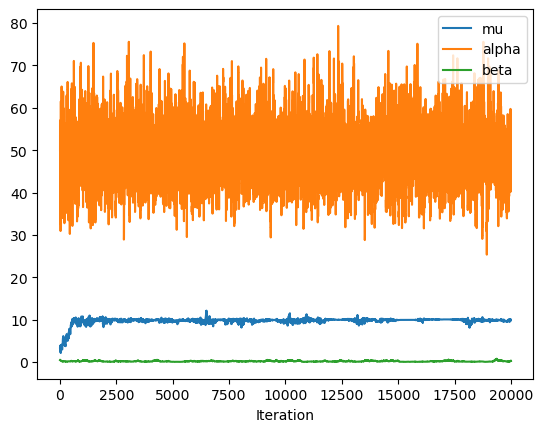

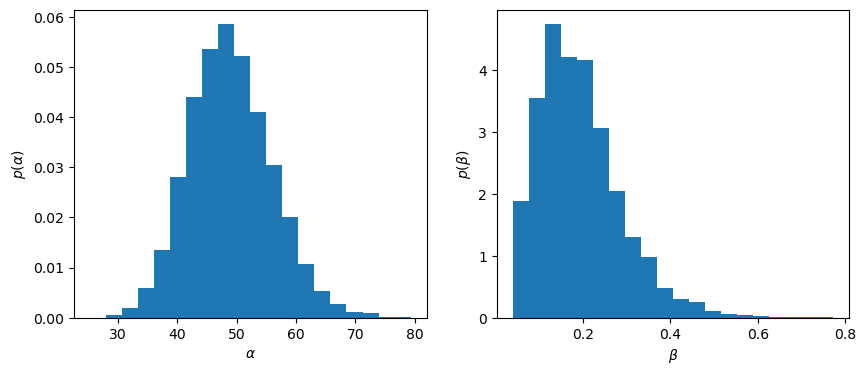

In [34]:
plt.plot(mu_chain)
plt.plot(alpha_chain);
plt.plot(beta_chain);
plt.legend(['mu', 'alpha', 'beta']);
plt.xlabel("Iteration");
plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.hist(alpha_chain[N_burnin:].numpy(), bins=20, density=True);
plt.xlabel("$\\alpha$")
plt.ylabel("$p(\\alpha)$")
plt.subplot(122)
plt.hist(beta_chain[N_burnin:].numpy(), bins=20, density=True);
plt.xlabel("$\\beta$")
plt.ylabel("$p(\\beta)$");

<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_851496/273400075.py:2: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("$\mu$")
/tmp/ipykernel_851496/273400075.py:3: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$p(\mu)$");


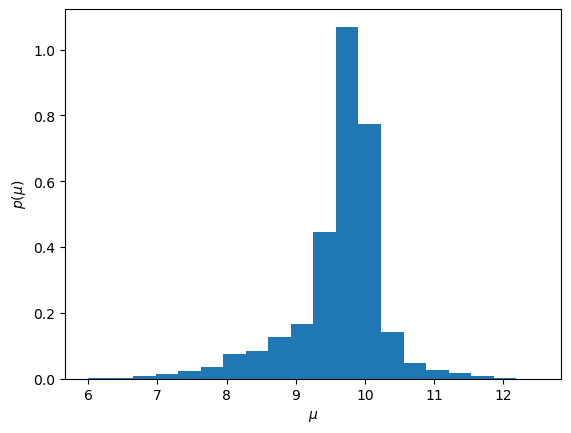

In [35]:
plt.hist(new_mu_chain[N_burnin:].numpy(), bins=20, density=True);
plt.xlabel("$\mu$")
plt.ylabel("$p(\mu)$");

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_851496/1670354910.py:3: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel("Estimated measurement std $\sigma_i$");


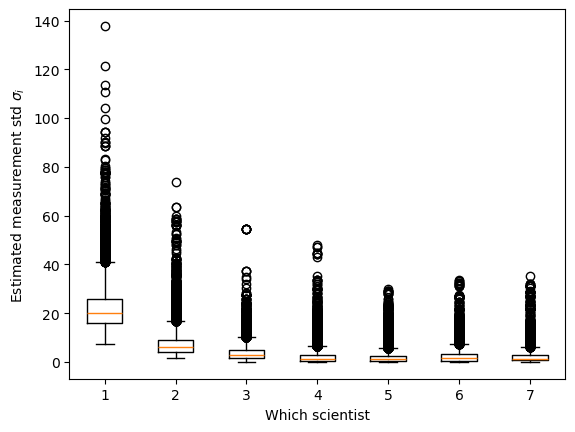

In [36]:
plt.boxplot(new_sigma_chain[N_burnin:].T, positions=np.arange(1, 8));
plt.xlabel("Which scientist")
plt.ylabel("Estimated measurement std $\sigma_i$");

In [ ]:
# (GRADING)

In [ ]:
# (GRADING)